# Ultralytics YOLO26x Production Video Pipeline on AMD Radeon

This notebook runs the complete workshop workflow:

```text
video -> rocDecode -> OpenCV HIP -> Ultralytics ONNX/MIGraphX -> GPU NMS
      -> async HIP overlay -> DRM PRIME VAAPI surface -> annotated base video
      -> Qwen3-VL temporal scenes -> CPU subtitle render -> final MP4
```

The schema 3 manifest prevents outputs from another ONNX, GPU, ROCm/MIGraphX, ORT, Ultralytics commit, workshop patch, production vision source, or native bridge source from being silently reused.

## 1. Verify the baked model set and runtime

In [1]:
import importlib
import json
import os
import sys
from pathlib import Path


def find_package_root() -> Path:
    origins = [Path.cwd(), *(Path(value) for value in sys.path if value)]
    for origin in origins:
        for candidate in (origin, *origin.parents):
            if (
                (candidate / "scripts/notebook_env.py").is_file()
                and (candidate / "src").is_dir()
                and (candidate / "data").is_dir()
            ):
                return candidate.resolve()
    raise FileNotFoundError("Run this notebook from the ultralytics_yolo26 folder")


ROOT = find_package_root()
os.environ["ULTRALYTICS_YOLO26_ROOT"] = str(ROOT)
os.environ["ULTRALYTICS_YOLO26_MODEL_DIR"] = str(ROOT / "models")
os.environ["ULTRALYTICS_YOLO26_OUTPUT_DIR"] = str(ROOT / "output")
os.environ.setdefault(
    "ULTRALYTICS_MIGRAPHX_CACHE_ROOT", str(ROOT / "models/ort-migraphx-cache")
)
os.environ.setdefault("HF_ENDPOINT", "https://hf-mirror.com")
for value in (str(ROOT), str(ROOT / "src")):
    if value not in sys.path:
        sys.path.insert(0, value)

from scripts import notebook_env as env
env = importlib.reload(env)
from scripts.model_setup import ensure_models, model_status
from scripts.notebook_helpers import frame_at, show_bgr, show_bgr_grid, video_info
from scripts.validate_runtime import validate

delivery_mode = (
    "baked/offline verification"
    if os.environ.get("ULTRALYTICS_WORKSHOP_BUNDLE") == "baked"
    else "development fallback download"
)
models = ensure_models(env.MODELS, progress=True)
runtime = validate(require_models=True, require_vlm=False)
print(json.dumps({"model_delivery": delivery_mode, **runtime}, indent=2))
models

[models] yolo26x.pt: verified baked model
[models] yolo26x.onnx: verified baked model
[models] Qwen3-VL-8B-Instruct-Q8_0.gguf: verified baked model
[models] mmproj-F16.gguf: verified baked model
[models] MIGraphX cache: /workspace/models/ort-migraphx-cache (verified baked gfx1100 cache)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/tmp/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


{
  "model_delivery": "baked/offline verification",
  "root": "/workspace",
  "src": "/workspace/src",
  "data": "/workspace/data",
  "models": "/workspace/models",
  "output": "/workspace/output",
  "opencv_install": "/opt/opencv5",
  "llamacpp": "http://ultralytics_yolo26_llamacpp:8199/v1",
  "python": "/opt/venv/bin/python3",
  "opencv": "5.1.0-dev",
  "opencv_hip_devices": 1,
  "torch": "2.9.1+gitff65f5b",
  "torch_gpu": "AMD Radeon PRO W7900D",
  "gpu_arch": "gfx1100",
  "ultralytics": "8.4.75",
  "onnxruntime": "1.24.2",
  "onnxruntime_providers": [
    "MIGraphXExecutionProvider",
    "CPUExecutionProvider"
  ],
  "migraphx_cache": "/workspace/models/ort-migraphx-cache"
}


[{'filename': 'yolo26x.pt',
  'source': 'ultralytics/assets@v8.4.0',
  'expected_gib': 0.111,
  'ready': True,
  'detail': 'ready',
  'path': '/workspace/models/yolo26x.pt'},
 {'filename': 'yolo26x.onnx',
  'source': 'ultralytics/assets@v8.4.0',
  'expected_gib': 0.208,
  'ready': True,
  'detail': 'ready',
  'path': '/workspace/models/yolo26x.onnx'},
 {'filename': 'Qwen3-VL-8B-Instruct-Q8_0.gguf',
  'source': 'unsloth/Qwen3-VL-8B-Instruct-GGUF',
  'expected_gib': 8.111,
  'ready': True,
  'detail': 'ready',
  'path': '/workspace/models/Qwen3-VL-8B-Instruct-Q8_0.gguf'},
 {'filename': 'mmproj-F16.gguf',
  'source': 'unsloth/Qwen3-VL-8B-Instruct-GGUF',
  'expected_gib': 1.079,
  'ready': True,
  'detail': 'ready',
  'path': '/workspace/models/mmproj-F16.gguf'}]

## 2. Initialize the Ultralytics-owned MIGraphX backend

In [2]:
from detector import UltralyticsYOLODetector

production_detector = UltralyticsYOLODetector(str(env.YOLO_ONNX), device_id=0)
provider = production_detector.provider_info()
print(json.dumps(provider, indent=2))
assert provider["owner"] == "ultralytics.YOLO"
assert provider["provider"] == "MIGraphXExecutionProvider"
assert provider["io_binding"] and provider["migraphx_fp16"]

[detector] Loading YOLO26x ONNX through Ultralytics...
[detector] MIGraphX cache identity: 735f1583e99dfeb733da
Loading /workspace/models/yolo26x.onnx for ONNX Runtime inference...


Using ONNX Runtime 1.24.2 with MIGraphXExecutionProvider


MIGraphX FP16 provider option is enabled; model input remains FP32.


2026-09-07 09:53:40.972433165 [W:onnxruntime:Default, migraphx_execution_provider.cc:167 MIGraphXExecutionProvider] [MIGraphX EP] MIGraphX ENV Override Variables Set:


[detector] Ultralytics ONNX + MIGraphX EP (FP16, GPU I/O binding) ready; output=(1, 300, 6)
{
  "owner": "ultralytics.YOLO",
  "ultralytics_format": "onnx",
  "provider": "MIGraphXExecutionProvider",
  "providers": [
    "MIGraphXExecutionProvider",
    "CPUExecutionProvider"
  ],
  "provider_options": {
    "migraphx_model_cache_dir": "\"/opt/ultralytics-yolo26/models/ort-migraphx-cache/735f1583e99dfeb733da\"",
    "device_id": "0",
    "migraphx_external_alloc": "0",
    "migraphx_fp8_enable": "0",
    "migraphx_int8_enable": "0",
    "migraphx_bf16_enable": "0",
    "migraphx_mem_limit": "18446744073709551615",
    "migraphx_int8_calibration_table_name": "",
    "migraphx_fp16_enable": "1",
    "migraphx_int8_use_native_calibration_table": "0",
    "migraphx_arena_extend_strategy": "kNextPowerOfTwo",
    "migraphx_exhaustive_tune": "0",
    "migraphx_external_free": "0",
    "migraphx_external_empty_cache": "0"
  },
  "io_binding": true,
  "migraphx_fp16": true,
  "cache_dir": "/opt

## 3. Inspect the source video

In [3]:
from IPython.display import HTML, display

source = video_info(env.SOURCE_VIDEO)
print(source)
source_url = "/files/" + env.SOURCE_VIDEO.relative_to(env.ROOT).as_posix()
display(HTML(
    f'<video controls preload="metadata" style="width:100%;max-width:960px" '
    f'src="{source_url}"></video>'
))

{'width': 1920, 'height': 1080, 'fps': 25.0, 'frames': 393, 'duration_seconds': 15.72}


## 4. Run or reuse the complete workflow

Set `RUN_PIPELINE=1` before starting the kernel to regenerate all 393 frames and force a fresh Qwen3-VL scene analysis. Otherwise the workflow validates the model/runtime identity in `manifest.json` before reusing saved artifacts.

In [4]:
from scripts import pipeline_workflow as workflow

RUN_PIPELINE = os.environ.get("RUN_PIPELINE", "0") == "1"
workflow_result = workflow.run_workflow(force=RUN_PIPELINE)
print(json.dumps(workflow_result, indent=2))

{
  "source": {
    "width": 1920,
    "height": 1080,
    "fps": 25.0,
    "frames": 393,
    "duration_seconds": 15.72,
    "codec": "h264",
    "profile": "High",
    "pixel_format": "yuv420p",
    "frame_rate": "25/1",
    "probe_duration_seconds": 15.72,
    "container_samples": 393,
    "packets": 393,
    "decoded_frames": 393
  },
  "yolo": {
    "width": 1920,
    "height": 1080,
    "fps": 25.0,
    "frames": 393,
    "duration_seconds": 15.72,
    "codec": "h264",
    "profile": "High",
    "pixel_format": "yuv420p",
    "frame_rate": "25/1",
    "probe_duration_seconds": 15.72,
    "container_samples": 393,
    "packets": 393,
    "decoded_frames": 393
  },
  "final": {
    "width": 1920,
    "height": 1220,
    "fps": 25.0,
    "frames": 393,
    "duration_seconds": 15.72,
    "codec": "h264",
    "profile": "High",
    "pixel_format": "yuv420p",
    "frame_rate": "25/1",
    "probe_duration_seconds": 15.72,
    "container_samples": 393,
    "packets": 393,
    "decoded_fr

## 5. Measure asynchronous GPU overlay and direct encode

The historical host-overlay/raw-BGR path reached 37.1 FPS and exposed the post-detection bottleneck. The current default removes full-frame D2H and overlaps the GPU overlay/VA-API worker with the next inference. The formal 393-frame workflow reached 74.7 FPS at host load 218.12; an independent repeat reached 71.9 FPS at load 209.15.

Worker latency and main-thread queue-feed latency are reported separately because the stages overlap. The saved workflow is accepted only when FPS is at least 50, full-frame D2H is zero, and all direct-encode submissions drain.

In [5]:
benchmark_path = env.OUTPUT / "benchmarks/gpu_stages.json"
gpu_benchmark = json.loads(benchmark_path.read_text())
manifest = json.loads(workflow.MANIFEST.read_text())
diagnosis = json.loads((env.OUTPUT / "benchmarks/performance_diagnosis.json").read_text())
print("GPU-resident detection stages:")
print(json.dumps(gpu_benchmark["stages"], indent=2))
print("GPU path:", gpu_benchmark["gpu_path_mean_ms"], "ms /", gpu_benchmark["gpu_path_fps"], "FPS")
performance = manifest["pipeline"]["performance"]
print("\nAsync direct annotated-video workflow:")
print(json.dumps(performance, indent=2))
print("\nHistorical residency and raw-pipe A/B evidence:")
print(json.dumps(diagnosis, indent=2))
assert performance["fps"] >= 50.0
assert performance["frame_d2h_ms"] == 0.0
assert performance["direct_encode_feed_ms"] < performance["gpu_overlay_direct_encode_worker_ms"]

GPU-resident detection stages:
{
  "decode": {
    "mean_ms": 2.656,
    "p50_ms": 0.94,
    "p95_ms": 5.412
  },
  "preprocess": {
    "mean_ms": 0.317,
    "p50_ms": 0.314,
    "p95_ms": 0.377
  },
  "inference": {
    "mean_ms": 14.214,
    "p50_ms": 14.427,
    "p95_ms": 16.1
  },
  "gpu_nms": {
    "mean_ms": 2.606,
    "p50_ms": 2.253,
    "p95_ms": 2.517
  }
}
GPU path: 19.793 ms / 50.5 FPS

Async direct annotated-video workflow:
{
  "fps": 74.7,
  "preprocess_ms": 0.59,
  "detection_ms": 10.44,
  "frame_d2h_ms": 0.0,
  "direct_encode_feed_ms": 0.15,
  "gpu_overlay_direct_encode_worker_ms": 7.85,
  "host_load_1m": 218.12,
  "direct_encode_queue_depth": 3,
  "direct_encode_submitted_frames": 393,
  "direct_encode_encoded_frames": 393
}

Historical residency and raw-pipe A/B evidence:
{
  "date": "2026-09-03",
  "host": {
    "logical_cpus": 128,
    "observed_load_average_range": [
      176.31,
      209.43
    ],
    "note": "Shared validation host under severe CPU load"
  },
 

## 6. Qwen3-VL temporal scene timeline

In [6]:
import pandas as pd

timeline = json.loads(workflow.TIMELINE.read_text())
segments = pd.DataFrame(timeline["segments"])[
    ["index", "start", "end", "caption", "latency_seconds"]
]
display(segments)
assert timeline["backend"] == "llamacpp"
assert "Q8_0.gguf" in timeline["model"]

,index,start,end,caption,latency_seconds
0,1,0.0,4.00,Pedestrians cross street as cars pass by in bu...,0.487195
1,2,4.0,8.00,Pedestrian crosses street as vehicles pass by ...,0.432809
2,3,8.0,12.00,Pedestrians and cyclist cross street near food...,0.436961
3,4,12.0,15.72,Pedestrians cross street as delivery truck pas...,0.428756


## 7. Play the final scene-aware video

In [7]:
final_info = video_info(workflow.FINAL_VIDEO)
print(final_info)
final_url = "/files/" + workflow.FINAL_VIDEO.relative_to(env.ROOT).as_posix()
display(HTML(
    f'<video controls preload="metadata" style="width:100%;max-width:960px" '
    f'src="{final_url}"></video>'
))
assert final_info["frames"] == source["frames"]

{'width': 1920, 'height': 1220, 'fps': 25.0, 'frames': 393, 'duration_seconds': 15.72}


## 8. Compare source, YOLO detection, and scene understanding

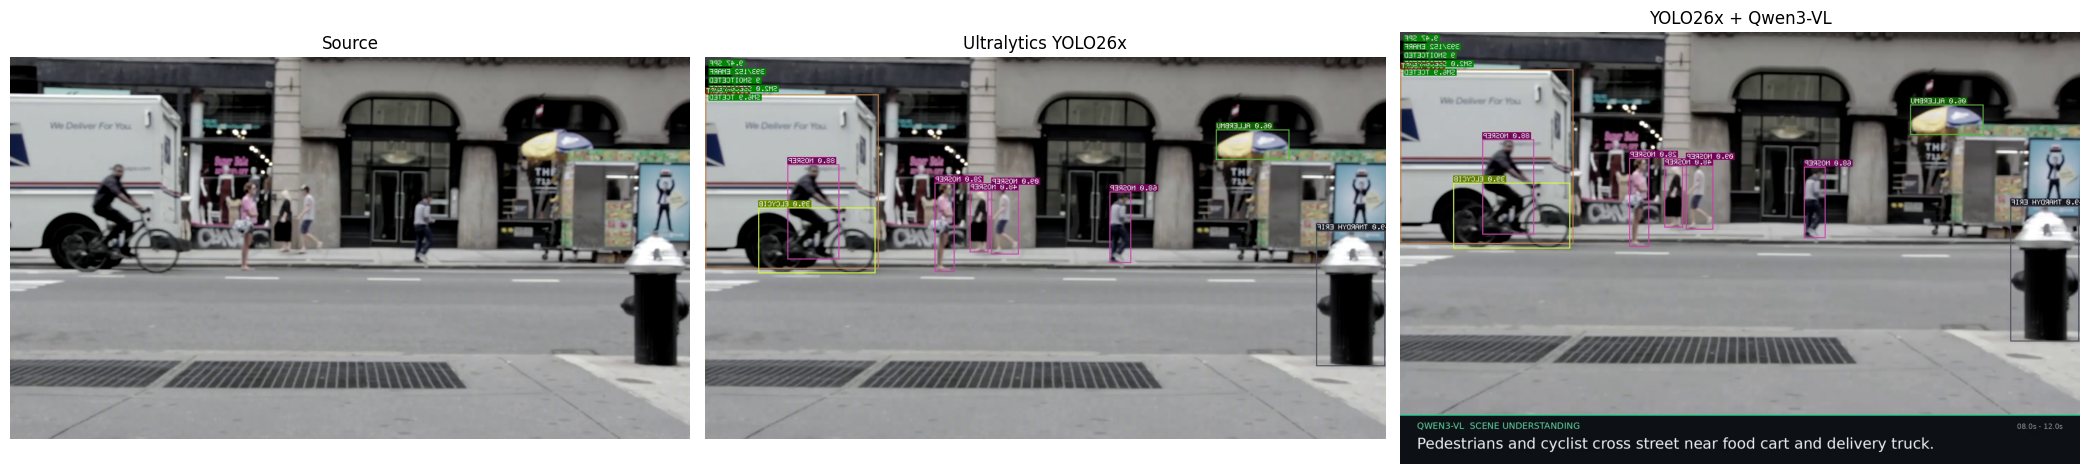

In [8]:
images = [
    frame_at(env.SOURCE_VIDEO, 10),
    frame_at(workflow.YOLO_VIDEO, 10),
    frame_at(workflow.FINAL_VIDEO, 10),
]
show_bgr_grid(
    images,
    ["Source", "Ultralytics YOLO26x", "YOLO26x + Qwen3-VL"],
    size=(21, 6),
)

## 9. Verify the reproducible artifact manifest

In [9]:
manifest_ready, manifest_detail = workflow.manifest_matches_current()
manifest = json.loads(workflow.MANIFEST.read_text())
print("manifest:", manifest_detail)
print(json.dumps({
    "schema_version": manifest["schema_version"],
    "runtime_identity": manifest["runtime_identity"],
    "models": manifest["models"],
    "artifacts": manifest["artifacts"],
}, indent=2))
assert manifest_ready and manifest["status"] == "PASS"
assert manifest["schema_version"] == 3
assert manifest["runtime_identity"]["hip_vaapi_bridge_sha256"]

manifest: ready for current model/GPU/runtime
{
  "schema_version": 3,
  "runtime_identity": {
    "schema_version": 1,
    "onnx_file": "yolo26x.onnx",
    "onnx_sha256": "88568299de91d4967f239a062c9f1619f695ebd05de73cd66b8f589591aaeb0a",
    "gpu_arch": "gfx1100",
    "gpu_name": "AMD Radeon PRO W7900D",
    "torch": "2.9.1+gitff65f5b",
    "torch_hip": "7.2.53211-e1a6bc5663",
    "migraphx": "2.15.0.dev+20250912-17-200-gde19b73ad",
    "onnxruntime": "1.24.2",
    "ultralytics": "8.4.75",
    "ultralytics_commit": "34e213ca3ece4c18962f5bb922ec74da0c474d24",
    "patch_sha256": "6c43dc90ae70bf61fc3f42634322d6a604a4a55cdc1542e5ea58f00af661c620",
    "provider": "MIGraphXExecutionProvider",
    "fp16": true,
    "input_shape": [
      1,
      3,
      640,
      640
    ],
    "output_shape": [
      1,
      300,
      6
    ],
    "checkpoint_sha256": "9fdd44a31c504547ffb81d2c6d9e6dac3493c8eaa8b0398d3f43bae6c7003e92",
    "hip_vaapi_bridge_sha256": "c239bb1752f9d2724bf83d60418f18a6c